In [93]:
import pipeline.calculate_metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [94]:
import gerrychain.grid

In [95]:
def populate_ch_grid(G, rho, M): #give graph x and y pop'scripts
    for node in G.graph.nodes:
        if G.graph.nodes[node]["sum"] % 2 == 0:
            G.graph.nodes[node]["x_pop"] = 0
            G.graph.nodes[node]["y_pop"] = M
        else:
            G.graph.nodes[node]["x_pop"] = 2 * M * rho
            G.graph.nodes[node]["y_pop"] = M * (1 - 2* rho)
    return G

In [ ]:
def generate_ch_grid(n: int, m: int, rho, M):
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["sum"] = node[0] + node[1]
    G = populate_ch_grid(G, rho, M)
    return G

In [97]:
def draw_grid(G):
    pos = {
        node: (
            G.graph.nodes[node]["x"],
            G.graph.nodes[node]["y"]
        )
        for node in G.graph.nodes
        }
    labels = {node: G.graph.nodes[node]["x_pop"] for node in G.graph.nodes}
    nx.draw(
        G.graph,
        node_size=1000,
        pos=pos,
        labels=labels
        )
    plt.show()


In [98]:
G = (generate_grid(90, 90, .2, 1000))

In [117]:
graphs =[]
rhos = np.linspace(0.01, .5, 20)
for rho in rhos: 
    graphs.append(generate_grid(90, 90, rho, 1000))

edge = [pipeline.calculate_metrics.edge(G.graph, "x_pop", "y_pop") for G in graphs]
half_edge = [pipeline.calculate_metrics.half_edge(G.graph, "x_pop", "y_pop") for G in graphs]

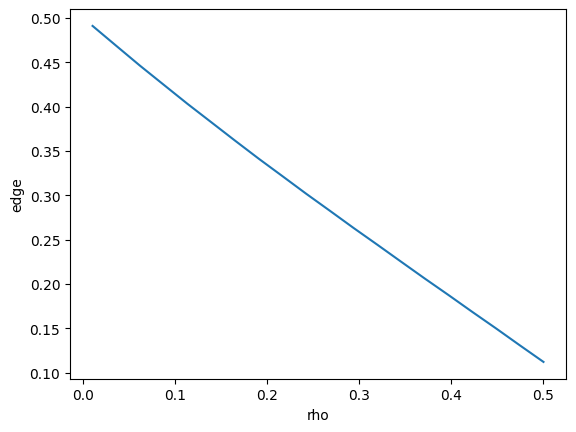

In [118]:
plt.plot(rhos, edge)
plt.xlabel("rho")
plt.ylabel("edge")
plt.show()

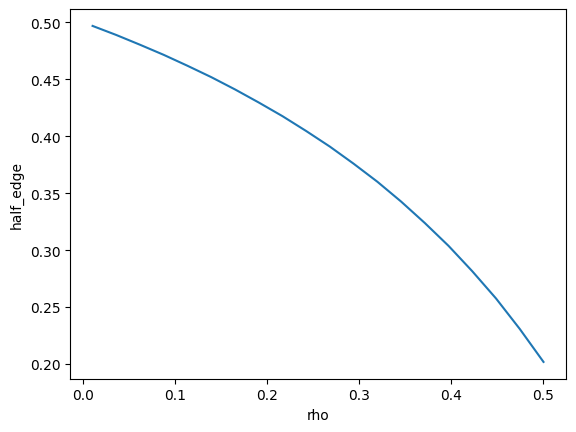

In [119]:
plt.plot(rhos, half_edge)
plt.xlabel("rho")
plt.ylabel("half_edge")
plt.show()

In [120]:
graphs = []
rhos = np.linspace(0.1, 1, 5)
for rho in rhos: 
    graphs.append(generate_grid(90, 90, rho, 1000))
    for G in graphs:
        try:
            pipeline.calculate_metrics.half_edge(G.graph, "x_pop", "y_pop")
        except ZeroDivisionError:
            print(rho)

1.0
